# Analysis of TBX2 and TBX3

In [23]:
# Importing dependencies
import pandas as pd
import warnings
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
import seaborn as sns
import networkx as nx
import re
import os

## Venn Diagram of Regulated Genes

In [24]:
# Set style for plots
sns.set_theme()
sns.set_palette("husl")

In [25]:
# Load data file paths 
excel_file = 'Diffentially Expressed Genes Tumour vs Normal.xlsx'
interactome_file = 'Human_Interactome.xlsx'

In [26]:
# Define groups
regGroups = ['Up Genes ', 'Down Genes ']
tumourGroups = ['High', 'Low']


 Running the analysis for High Tumors 



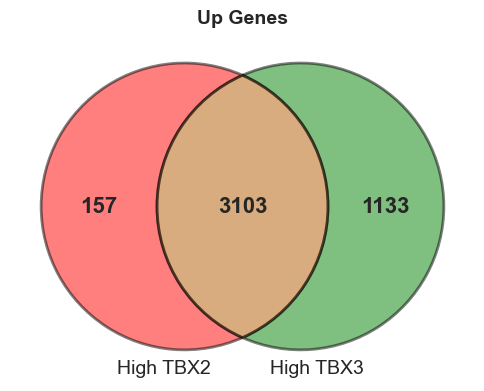

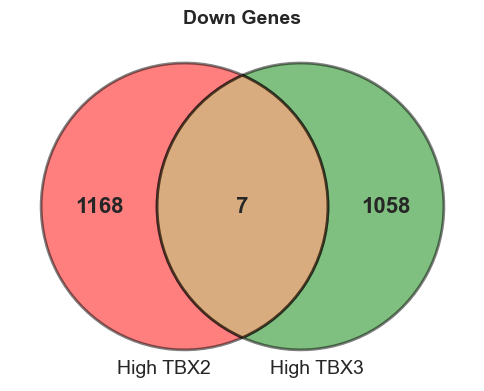


 Running the analysis for Low Tumors 



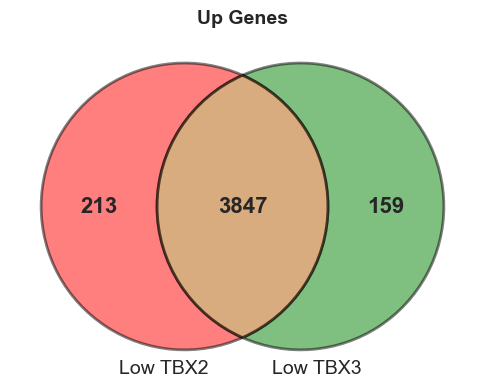

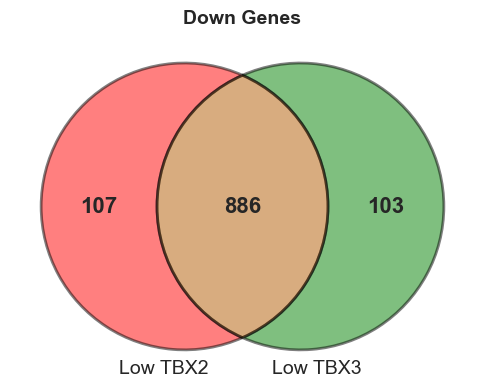

In [27]:
# Loop through tumour groups (outer loop)
for i in range(len(tumourGroups)):

    print(f"\n Running the analysis for {tumourGroups[i]} Tumors \n")

    # Inner loop for regulation groups
    for k in range(len(regGroups)):

        # ---------------- Load Data ----------------
        sheet_tb2 = regGroups[k] + tumourGroups[i] + " TBX2"
        sheet_tb3 = regGroups[k] + tumourGroups[i] + " TBX3"

        curTBX2 = pd.read_excel(excel_file, sheet_name=sheet_tb2)
        curTBX3 = pd.read_excel(excel_file, sheet_name=sheet_tb3)

        # ---------------- Find overlapping genes ----------------
        set1 = set(curTBX2['HugoSymbol'])
        set2 = set(curTBX3['HugoSymbol'])

        commonGenes = set1.intersection(set2)

        # ---------------- Calculate numbers ----------------
        onlyTBX2 = len(set1) - len(commonGenes)
        overlap = len(commonGenes)
        onlyTBX3 = len(set2) - len(commonGenes)

        # ---------------- Plot Venn ----------------
        plt.figure(figsize=(6,6))

        v = venn2(subsets=(1,1,1),
                  set_labels=None,
                  set_colors=('red','green'),
                  alpha=0.5)

        # Replace numbers
        v.get_label_by_id('10').set_text(onlyTBX2)
        v.get_label_by_id('11').set_text(overlap)
        v.get_label_by_id('01').set_text(onlyTBX3)

        # Bold numbers
        for label in ['10','11','01']:
            if v.get_label_by_id(label):
                v.get_label_by_id(label).set_fontweight('bold')
                v.get_label_by_id(label).set_fontsize(16)

        # Black outlines
        for patch in v.patches:
            if patch:
                patch.set_edgecolor('black')
                patch.set_linewidth(2)

        # Title 
        plt.title(regGroups[k].strip(), fontweight='bold', fontsize=14)

        # Bottom labels
        plt.text(0.33, 0.02, f"{tumourGroups[i]} TBX2",
                 transform=plt.gca().transAxes,
                 ha='center', fontsize=14)

        plt.text(0.66, 0.02, f"{tumourGroups[i]} TBX3",
                 transform=plt.gca().transAxes,
                 ha='center', fontsize=14)

        plt.axis('off')

        plt.show()

## Gene Set Enrichment Analysis Using Enrichr

In [6]:
diff_expr_file = "Diffentially Expressed Genes Tumour vs Normal.xlsx"
interactome_file = "Human_Interactome.xlsx"
enrichr_dir = "enrichr_results"

# CHeck whether the files exist
print(os.path.exists(diff_expr_file))
print(os.path.exists(interactome_file))
print(os.path.exists(enrichr_dir))

True
True
True


In [30]:
# Create an ExcelFile object to explore the workbook without loading every sheet in
excel_file = pd.ExcelFile(diff_expr_file)

for sheet in excel_file.sheet_names:
    # Print each sheet name to the console to verify they match the expected
    print(sheet)

High TBX2 vs Normal Pancreas
Up Genes High TBX2
Down Genes High TBX2
Low TBX2 vs Normal Pancreas
Up Genes Low TBX2
Down Genes Low TBX2
High TBX3 vs Normal Pancreas
Up Genes High TBX3
Down Genes High TBX3
Low TBX3 vs Normal Pancreas
Up Genes Low TBX3
Down Genes Low TBX3


In [64]:
# Load Excel file
file = "Diffentially Expressed Genes Tumour vs Normal.xlsx"

# Load sheets
tbx2 = pd.read_excel(file, sheet_name="Up Genes High TBX2")
tbx3 = pd.read_excel(file, sheet_name="Up Genes High TBX3")

# Extract gene symbols
tbx2_genes = tbx2["HugoSymbol"]
tbx3_genes = tbx3["HugoSymbol"]

# Save to text files
tbx2_genes.to_csv("high_tbx2_genes.txt", index=False, header=False)
tbx3_genes.to_csv("high_tbx3_genes.txt", index=False, header=False)

print("Gene lists created.")

Gene lists created.


In [66]:
!python enrichr_analysis_assg.py

User List ID: 123944349
Results for Achilles_fitness_decrease saved to enrichr_results\High TBX3 Achilles_fitness_decrease_table.txt
Results for Achilles_fitness_increase saved to enrichr_results\High TBX3 Achilles_fitness_increase_table.txt
Results for ChEA_2022 saved to enrichr_results\High TBX3 ChEA_2022_table.txt
Results for ClinVar_2019 saved to enrichr_results\High TBX3 ClinVar_2019_table.txt
Results for Drug_Perturbations_from_GEO_2014 saved to enrichr_results\High TBX3 Drug_Perturbations_from_GEO_2014_table.txt
Results for Drug_Perturbations_from_GEO_down saved to enrichr_results\High TBX3 Drug_Perturbations_from_GEO_down_table.txt
Results for Drug_Perturbations_from_GEO_up saved to enrichr_results\High TBX3 Drug_Perturbations_from_GEO_up_table.txt
Results for GO_Biological_Process_2023 saved to enrichr_results\High TBX3 GO_Biological_Process_2023_table.txt
Results for GO_Cellular_Component_2023 saved to enrichr_results\High TBX3 GO_Cellular_Component_2023_table.txt
Results for

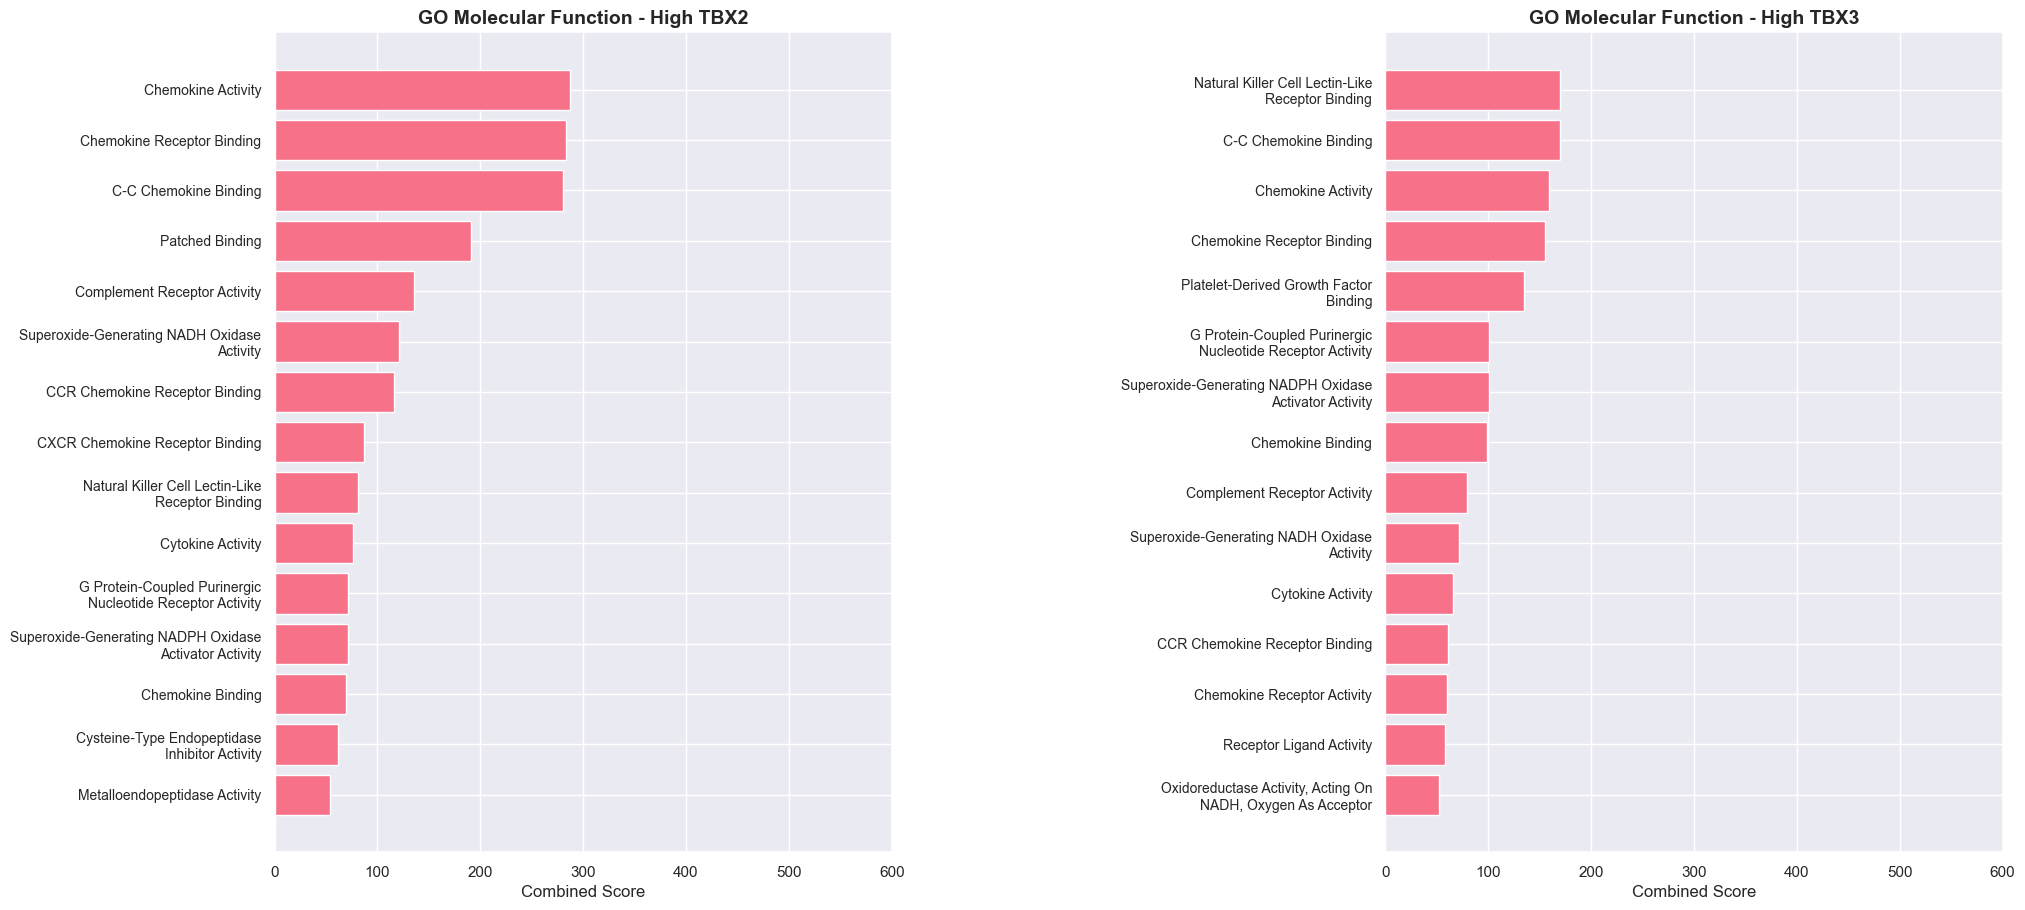

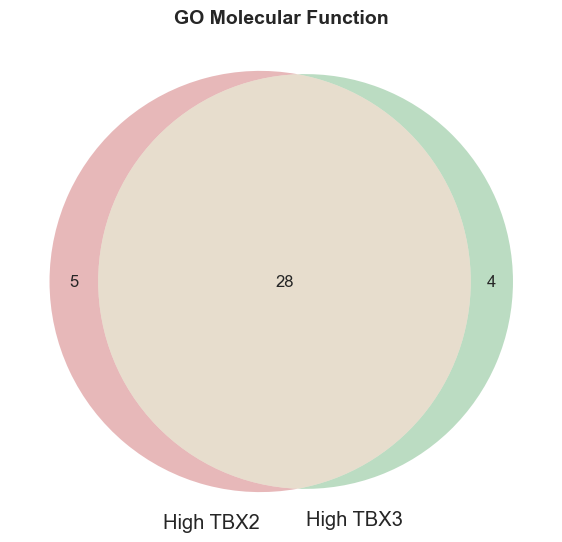

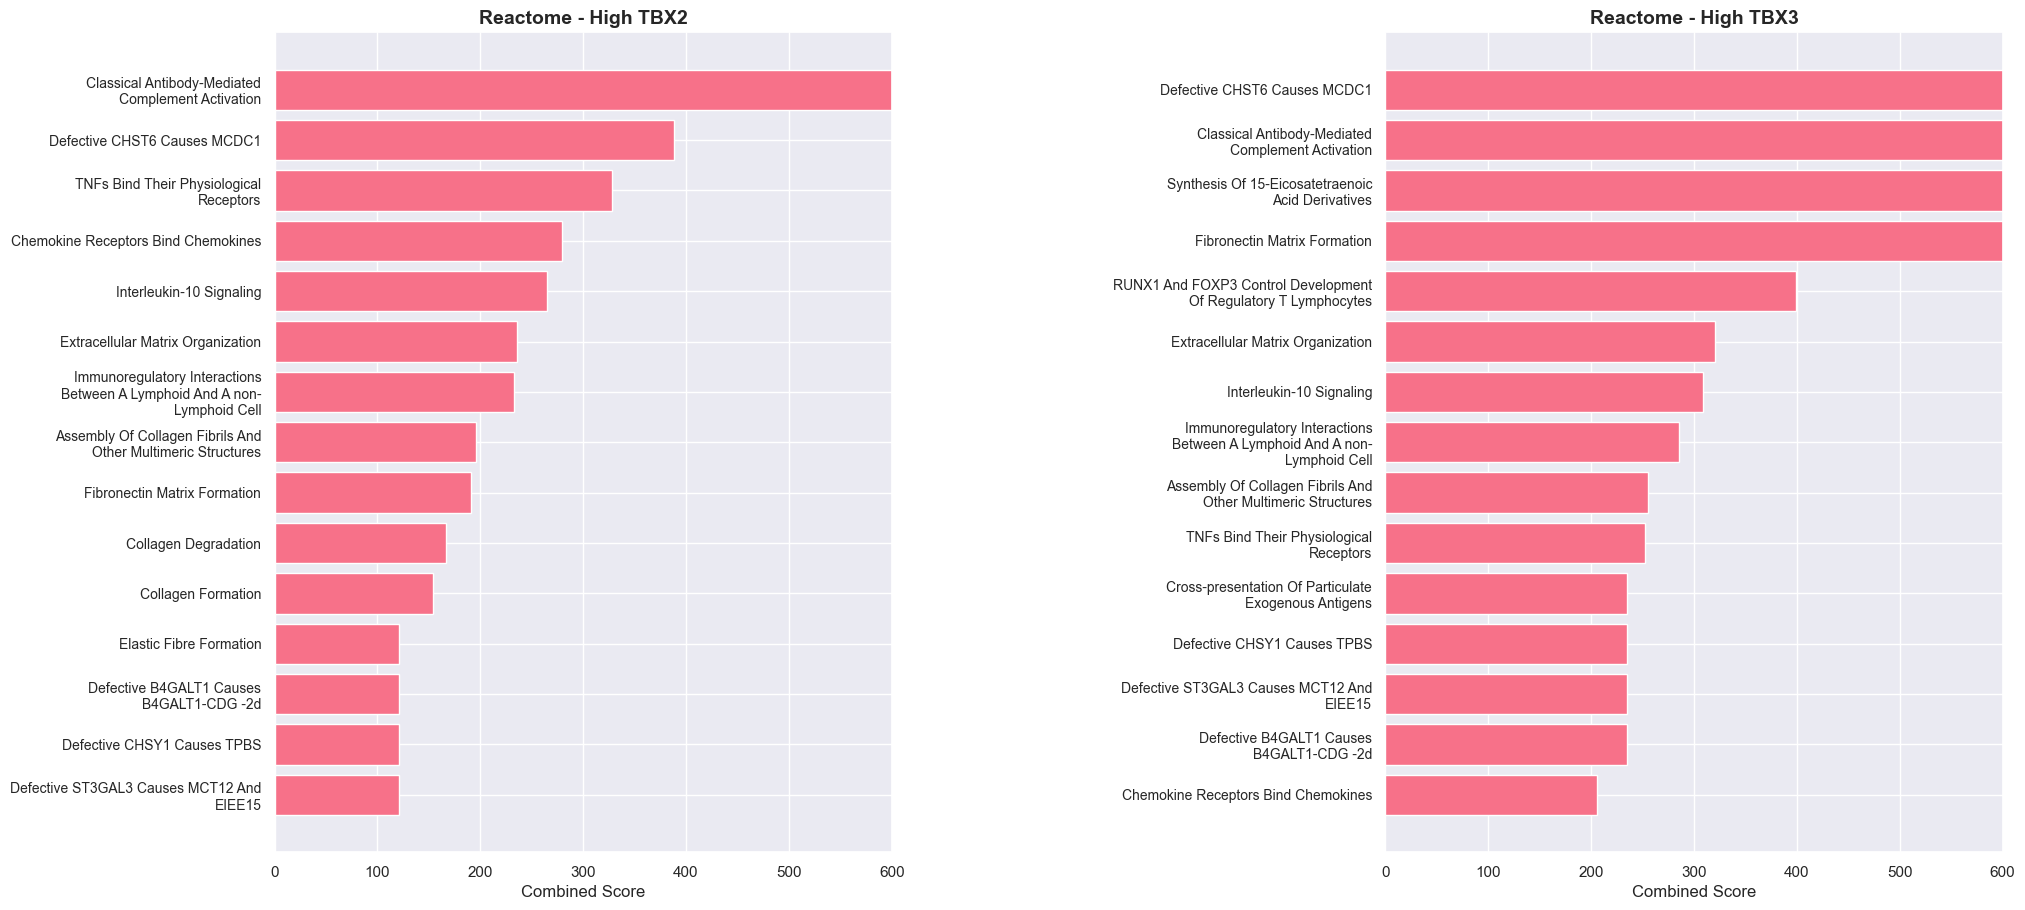

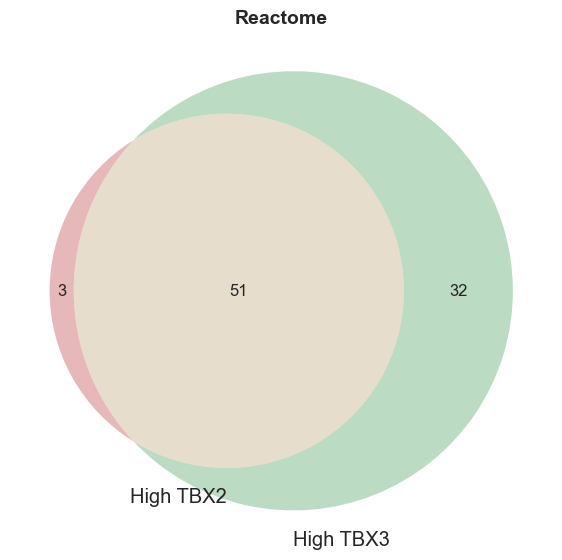

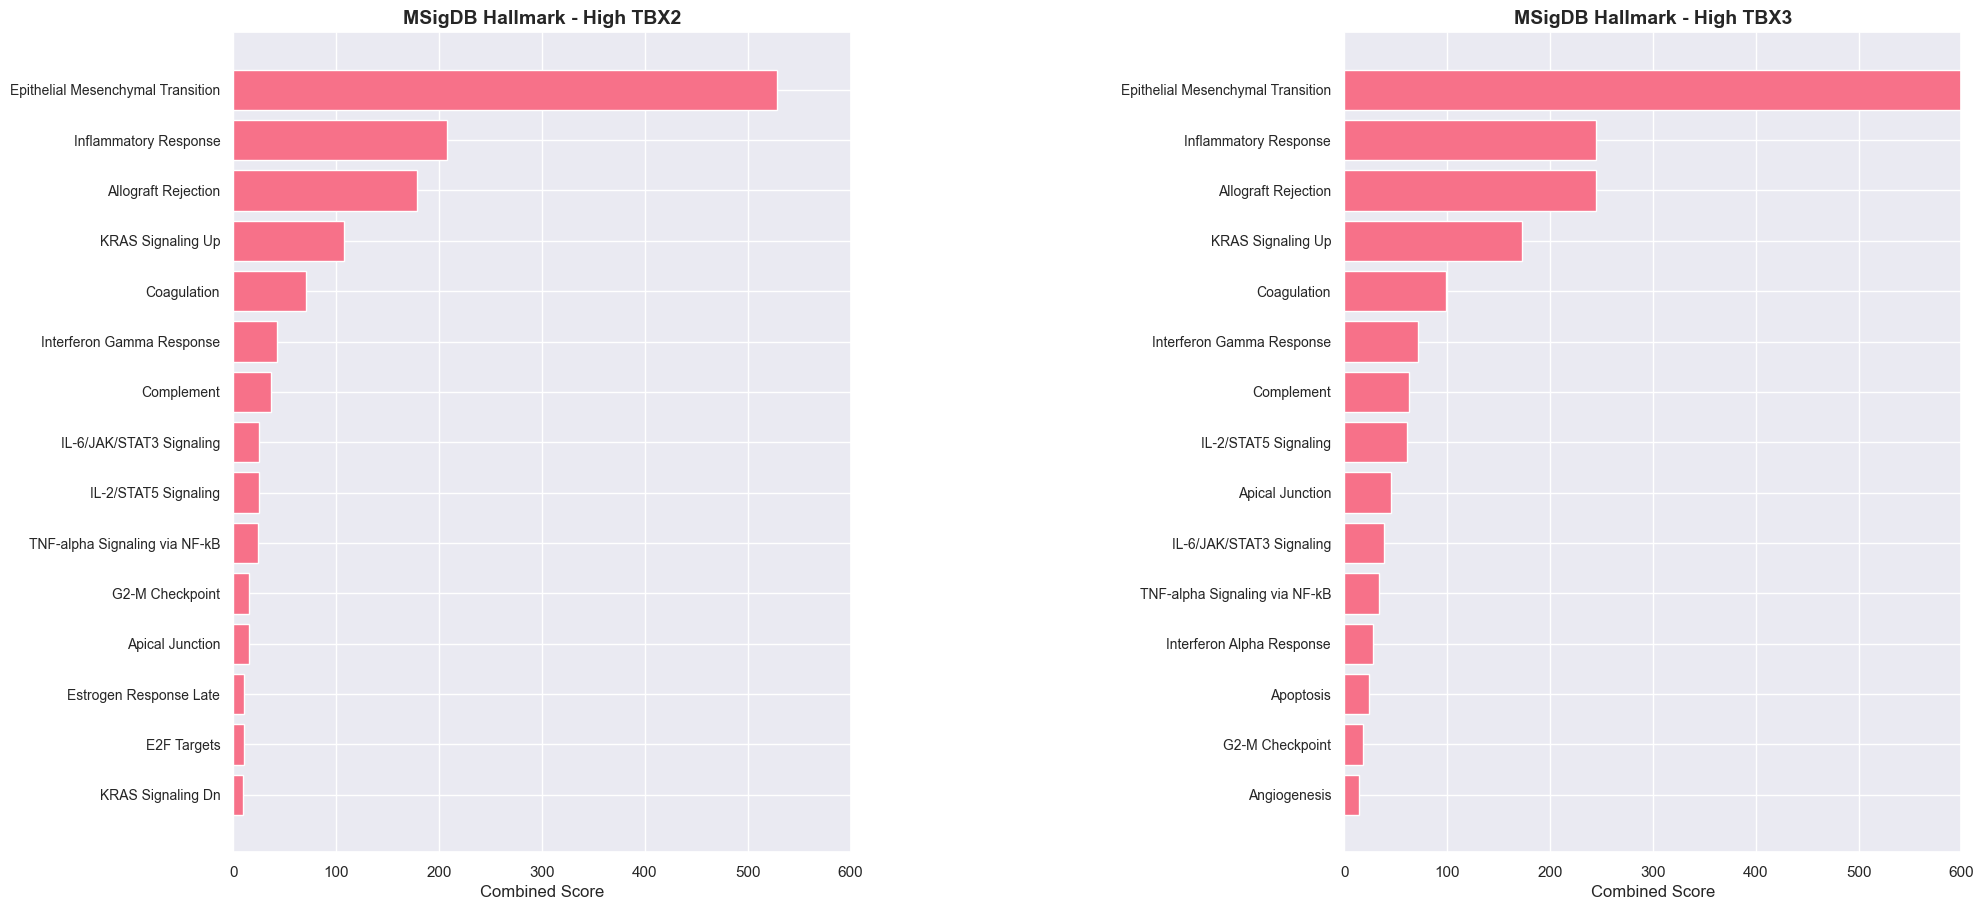

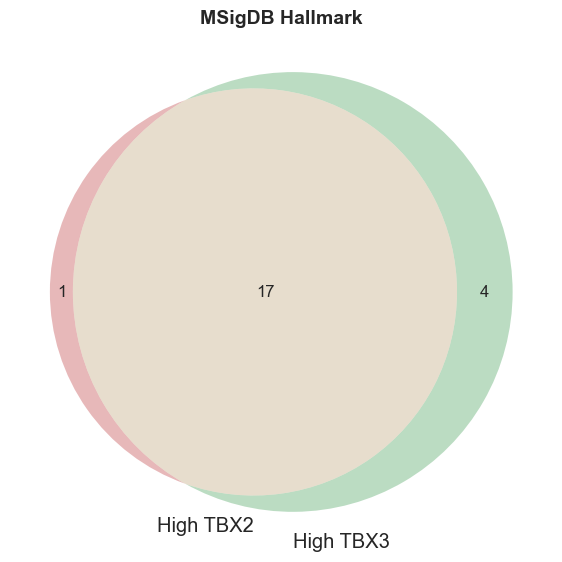

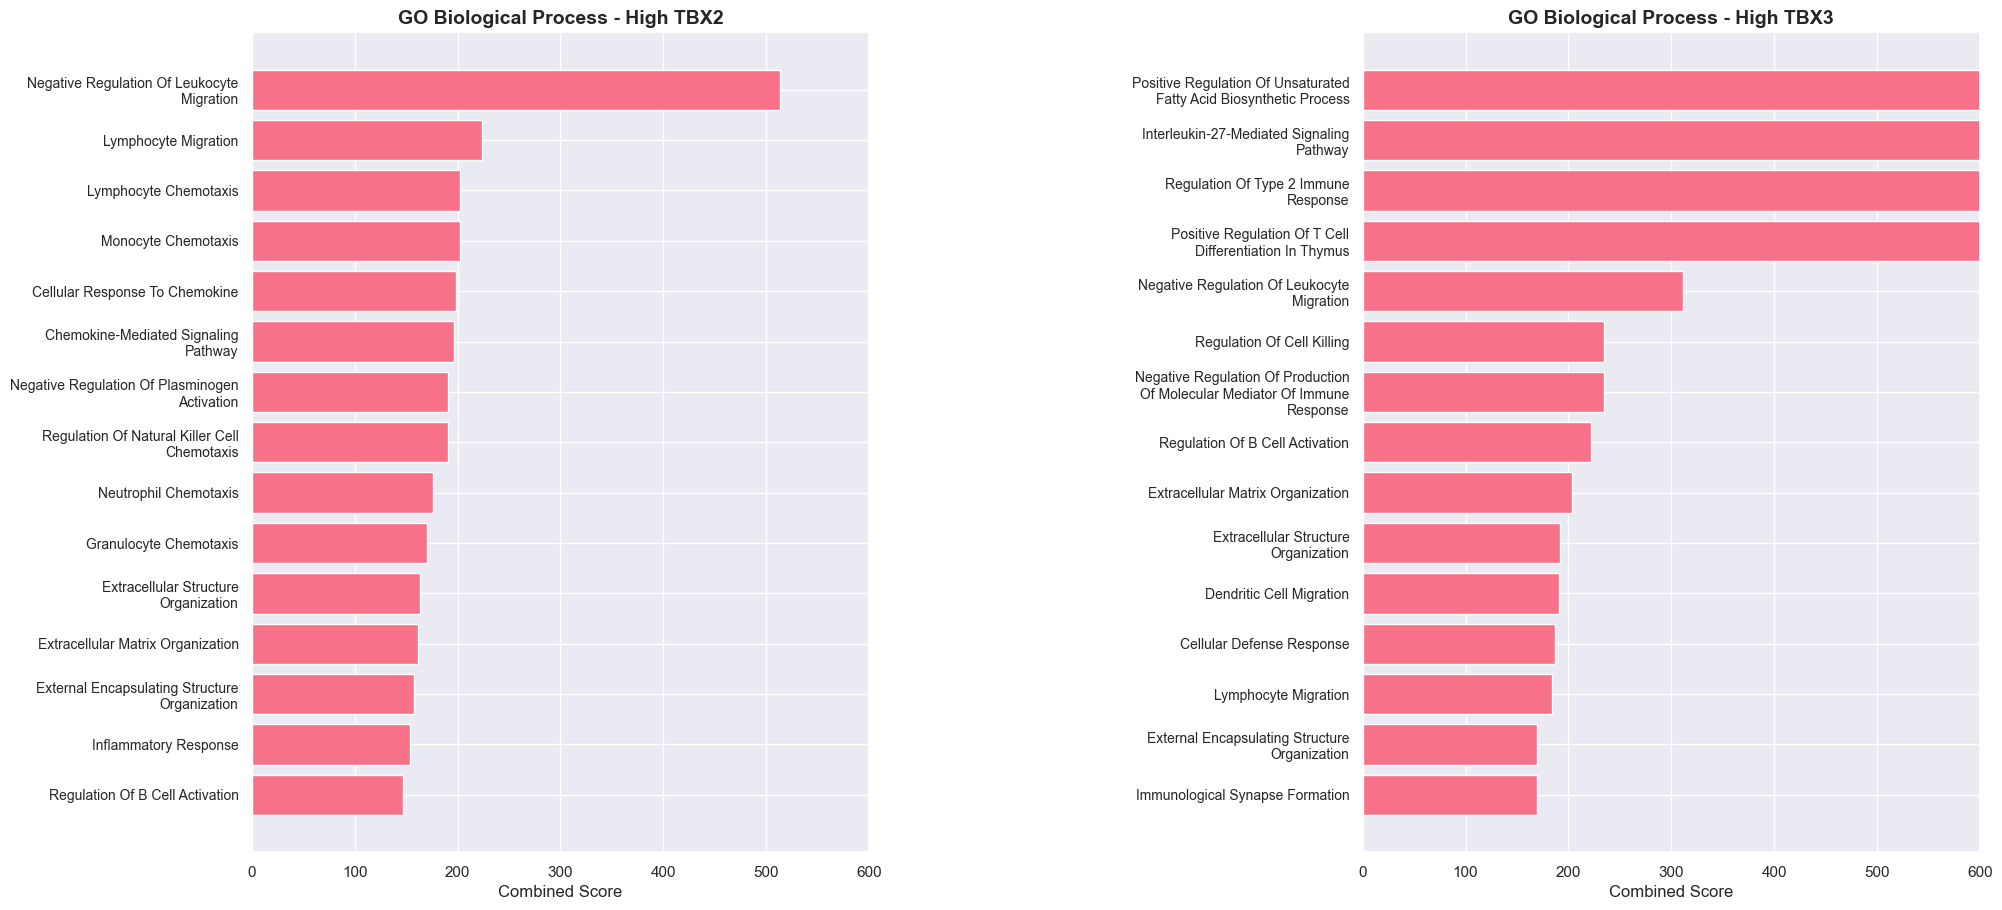

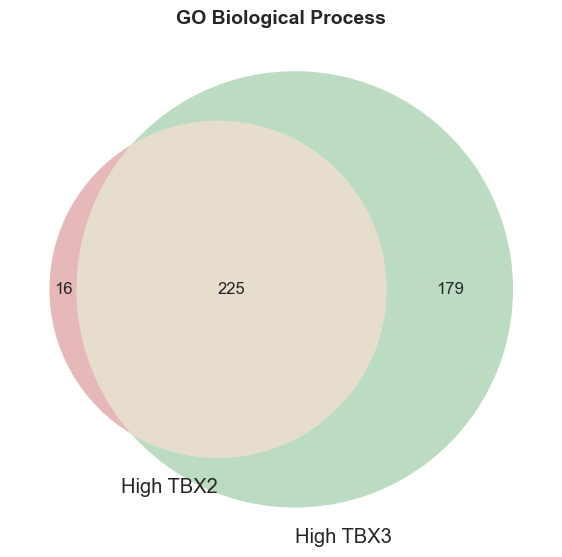

In [33]:
import os
import re
import textwrap
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

enrichr_dir = "enrichr_results"

enrichr_files = [
    "GO_Molecular_Function_2023_table.txt",
    "Reactome_2022_table.txt",
    "MSigDB_Hallmark_2020_table.txt",
    "GO_Biological_Process_2023_table.txt"
]

plot_names = [
    "GO Molecular Function",
    "Reactome",
    "MSigDB Hallmark",
    "GO Biological Process"
]

def clean_term(term):
    term = str(term)
    term = re.sub(r"\(+\w*", "", term)
    term = re.sub(r"\:+\w*", "", term)
    term = re.sub(r"\)", "", term)
    term = re.sub(r"R-HSA-\w*", "", term)
    term = re.sub(r"Homo sapiens", "", term)
    term = re.sub(r"\w* raw", "", term)
    term = re.sub(r"\s+", " ", term)
    return term.strip()

def wrap_term(term, width=38):
    return textwrap.fill(str(term), width=width)

def load_enrichr_file(path):
    df = pd.read_csv(path, sep="\t")
    df.columns = [str(c).replace(" ", "_").replace("-", "_") for c in df.columns]
    df["Term"] = df["Term"].apply(clean_term)
    df = df[df["Term"] != ""].copy()
    return df

for enrichr_file, plot_name in zip(enrichr_files, plot_names):

    tbx2_file = os.path.join(enrichr_dir, f"High TBX2 {enrichr_file}")
    tbx3_file = os.path.join(enrichr_dir, f"High TBX3 {enrichr_file}")

    tbx2 = load_enrichr_file(tbx2_file)
    tbx3 = load_enrichr_file(tbx3_file)

    score_col = "CombinedScore" if "CombinedScore" in tbx2.columns else "Combined_Score"
    pval_col = "AdjustedP_value" if "AdjustedP_value" in tbx2.columns else "Adjusted_P_value"

    tbx2[score_col] = pd.to_numeric(tbx2[score_col], errors="coerce")
    tbx3[score_col] = pd.to_numeric(tbx3[score_col], errors="coerce")
    tbx2[pval_col] = pd.to_numeric(tbx2[pval_col], errors="coerce")
    tbx3[pval_col] = pd.to_numeric(tbx3[pval_col], errors="coerce")

    # FIX 1: filter significant pathways first
    tbx2_sig = tbx2[tbx2[pval_col] < 0.05].copy()
    tbx3_sig = tbx3[tbx3[pval_col] < 0.05].copy()

    # FIX 2: remove duplicate cleaned term names
    tbx2_sig = tbx2_sig.drop_duplicates(subset="Term")
    tbx3_sig = tbx3_sig.drop_duplicates(subset="Term")

    # FIX 3: then select top pathways by score
    tbx2_top = tbx2_sig.sort_values(score_col, ascending=False).head(15).copy()
    tbx3_top = tbx3_sig.sort_values(score_col, ascending=False).head(15).copy()

    # FIX 4: wrap long labels so Reactome does not look broken
    tbx2_top["WrappedTerm"] = tbx2_top["Term"].apply(lambda x: wrap_term(x, width=35))
    tbx3_top["WrappedTerm"] = tbx3_top["Term"].apply(lambda x: wrap_term(x, width=35))

    fig, axes = plt.subplots(1, 2, figsize=(24, 10))

    axes[0].barh(tbx2_top["WrappedTerm"][::-1], tbx2_top[score_col][::-1])
    axes[0].set_title(f"{plot_name} - High TBX2", fontsize=14, fontweight="bold")
    axes[0].set_xlabel("Combined Score")
    axes[0].invert_yaxis()
    axes[0].tick_params(axis="y", labelsize=10)
    axes[0].invert_yaxis()
    axes[0].set_xlim(0, 600)
    

    axes[1].barh(tbx3_top["WrappedTerm"][::-1], tbx3_top[score_col][::-1])
    axes[1].set_title(f"{plot_name} - High TBX3", fontsize=14, fontweight="bold")
    axes[1].set_xlabel("Combined Score")
    axes[1].invert_yaxis()
    axes[1].tick_params(axis="y", labelsize=10)
    axes[1].invert_yaxis()
    axes[1].set_xlim(0, 600)
    
    

    plt.subplots_adjust(wspace=0.8, left=0.25, right=0.97, top=0.90, bottom=0.08)
    plt.show()

    set1 = set(tbx2_sig["Term"])
    set2 = set(tbx3_sig["Term"])

    plt.figure(figsize=(7, 7))
    venn2([set1, set2], set_labels=("High TBX2", "High TBX3"))
    plt.title(plot_name, fontsize=14, fontweight="bold")
    plt.show()

## Create a Network of Genes

Reading the Human Interactome Data


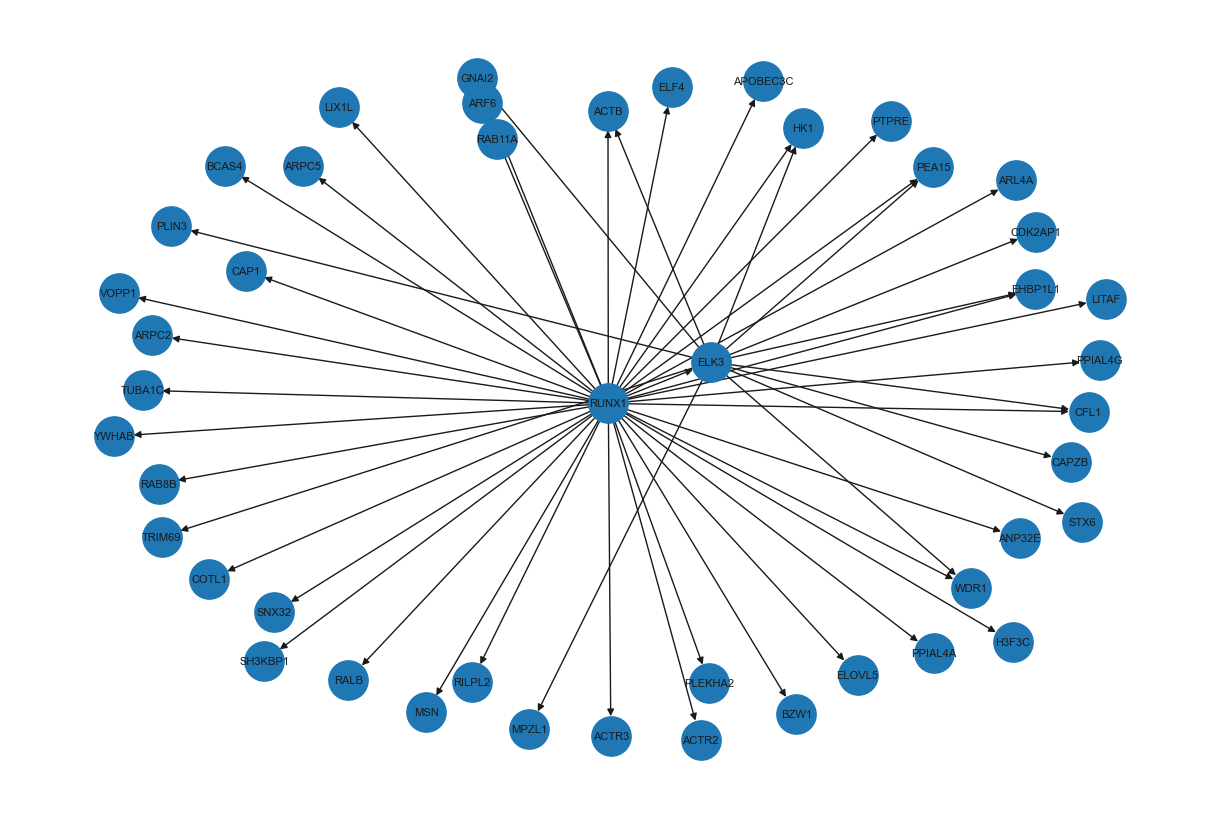

In [37]:
# File containing the differentially expressed genes (Tumour vs Normal comparison)
diff_expr_file = "Diffentially Expressed Genes Tumour vs Normal.xlsx"

# File containing the human protein–protein interaction dataset
interactome_file = "Human_Interactome.xlsx"


# Read the sheet that contains genes that are upregulated in High TBX3 samples
the_up_genes = pd.read_excel(diff_expr_file, sheet_name="Up Genes High TBX3")


# Extract the gene symbols we want to analyse
my_genes = (
    the_up_genes["HugoSymbol"]   # Select the gene symbol column
    .dropna()                    # Remove any missing gene names
    .astype(str)                 # Convert all entries to strings
    .str.strip()                 # Remove leading/trailing spaces
    .head(100)                   # Only keep the top 100 genes
    .tolist()                    # Convert the column to a Python list
)


print("Reading the Human Interactome Data")

# Load the protein interaction dataset
interactome = pd.read_excel(interactome_file)


# Filter interactions where BOTH interacting proteins are in our gene list
network = interactome[
    interactome["Protein1"].astype(str).str.strip().isin(my_genes) &
    interactome["Protein2"].astype(str).str.strip().isin(my_genes)
].copy()


# Remove self-interactions (cases where a protein interacts with itself)
network = network[
    network["Protein1"].astype(str).str.strip() !=
    network["Protein2"].astype(str).str.strip()
].copy()


# Create a column marking whether the source protein is differentially expressed
# (1 = yes, 0 = no)
network["DiffExpressed"] = (
    network["Protein1"].astype(str).str.strip().isin(my_genes).astype(int)
)


# Clean the interaction type formatting (for compatibility with tools like yED)
network["Interaction"] = (
    network["Interaction"].astype(str).str.replace("-t>", "->t", regex=False)
)

# Save the filtered interaction network to an Excel file
# This file can be imported into network visualisation tools
network.to_excel("yED_networks.xlsx", sheet_name="UpGenes TBX3", index=False)

# Create a directed graph object using NetworkX
G = nx.DiGraph()


# Add edges to the graph for each protein interaction
for _, row in network.iterrows():
    
    # Extract source and target proteins
    source = str(row["Protein1"]).strip()
    target = str(row["Protein2"]).strip()

    # Add the interaction as a directed edge
    G.add_edge(source, target)


# Create a visualisation of the interaction network
plt.figure(figsize=(12,8))

# Generate node positions using a force-directed layout
pos = nx.spring_layout(G)

# Draw the graph
nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=800,
    font_size=8
)

# Display the network plot
plt.show()